# 01 — EDA & Synthetic Grocery Data Generation

**Goal:** Generate the synthetic grocery-sales dataset defined in `src/data_generator.py`,
inspect its schema and data quality, and validate the seasonal/promotion effects that the
generator intentionally creates.

This notebook is aligned to the current project source code:
`generate_grocery_sales(..., seed=42)` and `save_outputs(...)`.

In [13]:
# Cell 1 — Imports & Setup

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_SEED = 42
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))

from src.data_generator import generate_grocery_sales, save_outputs

print("Project root:", ROOT)
print("Random seed:", RANDOM_SEED)

Project root: c:\Users\Bhavya\Desktop\ML\OptiPerish
Random seed: 42


## What are we generating?

The current generator creates:

- 2 years of daily data
- 8 stores
- 8 grocery items
- 4 categories
- promotion flags
- prices and costs
- shelf-life information
- stochastic supplier lead-time metadata

The target we eventually forecast is `sales_units`.

In [14]:
# Cell 2 — Data Generation & Ingestion
# IMPORTANT: the actual source function uses `seed`, not `random_state`.

df, lead_time_meta = generate_grocery_sales(seed=RANDOM_SEED)
save_outputs(df, lead_time_meta)

print(f"Total Records: {len(df):,}")
display(df.head(10))

Saved grocery sales to C:\Users\Bhavya\Desktop\ML\OptiPerish\data\raw\grocery_sales.csv
Saved lead time metadata to C:\Users\Bhavya\Desktop\ML\OptiPerish\data\raw\lead_time_metadata.json
Total Records: 46,720


,date,store_id,item_id,category,sales_units,on_promotion,base_price,unit_cost,shelf_life_days,holding_cost_per_day,spoilage_cost_per_unit,stockout_cost_per_unit
0,2024-01-01,STORE_01,ITEM_BAKERY_01,Bakery,14,0,50.27,33.26,3,0.91,40.08,65.52
1,2024-01-01,STORE_01,ITEM_BAKERY_02,Bakery,20,0,25.81,15.17,3,0.32,19.05,59.95
2,2024-01-01,STORE_01,ITEM_DAIRY_01,Dairy,48,0,63.19,35.81,7,1.68,42.30,75.08
3,2024-01-01,STORE_01,ITEM_DAIRY_02,Dairy,32,0,38.16,20.59,7,0.51,28.70,66.99
4,2024-01-01,STORE_01,ITEM_MEAT_01,Meat,15,0,204.22,123.73,5,4.66,130.55,116.44
5,2024-01-01,STORE_01,ITEM_MEAT_02,Meat,12,0,130.79,64.24,5,1.37,69.95,109.70
6,2024-01-01,STORE_01,ITEM_PRODUCE_01,Produce,21,0,35.55,16.13,4,0.62,22.23,66.98
7,2024-01-01,STORE_01,ITEM_PRODUCE_02,Produce,15,0,22.92,13.80,4,0.51,19.98,58.59
8,2024-01-01,STORE_02,ITEM_BAKERY_01,Bakery,20,0,50.12,33.73,3,0.91,39.86,67.67
9,2024-01-01,STORE_02,ITEM_BAKERY_02,Bakery,16,0,25.37,15.28,3,0.32,19.91,58.16


In [15]:
# Cell 3 — Data Integrity & Schema Check

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
missing = (
    df.isna()
      .sum()
      .rename("missing_count")
      .to_frame()
)
missing["missing_pct"] = (
    missing["missing_count"] / len(df) * 100
)
display(missing)

print("Duplicate rows:", int(df.duplicated().sum()))

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Shape: (46720, 12)

Columns:
['date', 'store_id', 'item_id', 'category', 'sales_units', 'on_promotion', 'base_price', 'unit_cost', 'shelf_life_days', 'holding_cost_per_day', 'spoilage_cost_per_unit', 'stockout_cost_per_unit']

Data types:


,dtype
date,datetime64[ns]
store_id,object
item_id,object
category,object
sales_units,int64
on_promotion,int64
base_price,float64
unit_cost,float64
shelf_life_days,int64
holding_cost_per_day,float64



Missing values:


,missing_count,missing_pct
date,0,0.0
store_id,0,0.0
item_id,0,0.0
category,0,0.0
sales_units,0,0.0
on_promotion,0,0.0
base_price,0,0.0
unit_cost,0,0.0
shelf_life_days,0,0.0
holding_cost_per_day,0,0.0


Duplicate rows: 0

Descriptive statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,46720,NaN,NaN,NaN,2024-12-30 12:00:00,2024-01-01 00:00:00,2024-07-01 00:00:00,2024-12-30 12:00:00,2025-07-01 00:00:00,2025-12-30 00:00:00,NaN
store_id,46720,8,STORE_01,5840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_id,46720,8,ITEM_BAKERY_01,5840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,46720,4,Bakery,11680,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales_units,46720.0,NaN,NaN,NaN,29.922881,2.0,17.0,25.0,37.0,165.0,17.77084
on_promotion,46720.0,NaN,NaN,NaN,0.04161,0.0,0.0,0.0,0.0,1.0,0.199697
base_price,46720.0,NaN,NaN,NaN,69.01325,21.63,29.9975,44.2,79.795,206.53,56.764217
unit_cost,46720.0,NaN,NaN,NaN,40.624333,13.36,15.82,26.82,43.755,129.83,35.477147
shelf_life_days,46720.0,NaN,NaN,NaN,4.75,3.0,3.75,4.5,5.5,7.0,1.479036
holding_cost_per_day,46720.0,NaN,NaN,NaN,1.333924,0.29,0.51,0.75,1.51,5.11,1.374139


In [16]:
# Cell 4 — Date, Store and Item Coverage

df["date"] = pd.to_datetime(df["date"])

print("Date range:", df["date"].min(), "to", df["date"].max())
print("Unique dates:", df["date"].nunique())
print("Stores:", df["store_id"].nunique())
print("Items:", df["item_id"].nunique())
print("Categories:", df["category"].nunique())

print("\nCategory counts:")
display(df["category"].value_counts().to_frame("rows"))

print("\nLead-time metadata example:")
first_item = next(iter(lead_time_meta))
print(first_item, "→", lead_time_meta[first_item])

Date range: 2024-01-01 00:00:00 to 2025-12-30 00:00:00
Unique dates: 730
Stores: 8
Items: 8
Categories: 4

Category counts:


,rows
category,
Bakery,11680
Dairy,11680
Meat,11680
Produce,11680



Lead-time metadata example:
ITEM_DAIRY_01 → {2: 0.11918293634904525, 3: 0.5089914835411513, 5: 0.2712259223412653, 7: 0.100599657768538}


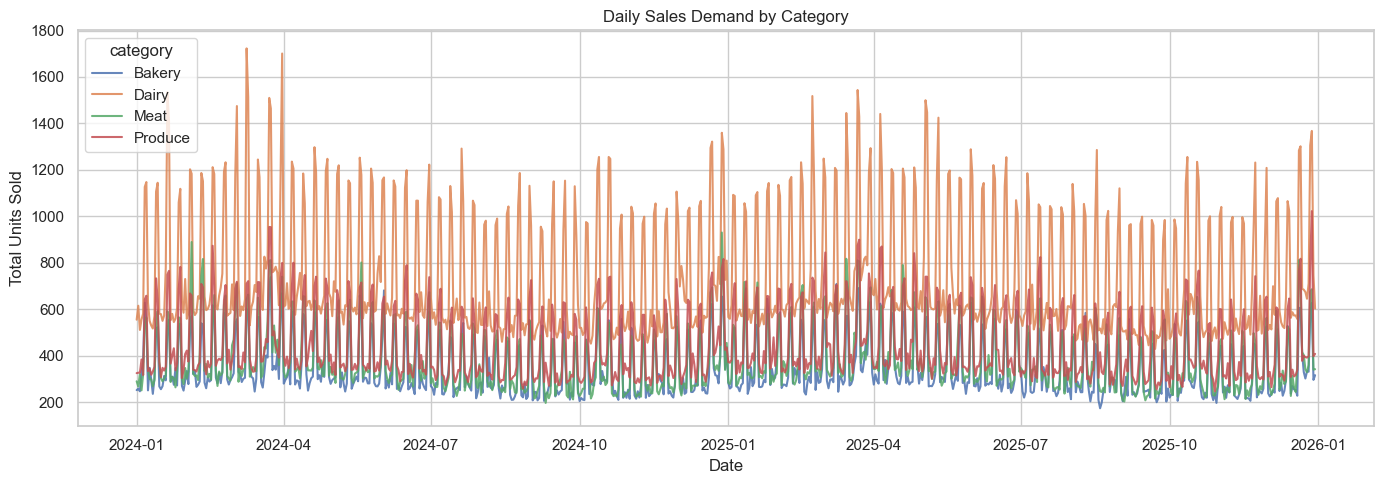

In [17]:
# Cell 5 — Category-Level Sales Trend

category_daily = (
    df.groupby(["date", "category"], as_index=False)["sales_units"]
      .sum()
)

plt.figure(figsize=(14, 5))
sns.lineplot(
    data=category_daily,
    x="date",
    y="sales_units",
    hue="category",
    alpha=0.85,
)
plt.title("Daily Sales Demand by Category")
plt.xlabel("Date")
plt.ylabel("Total Units Sold")
plt.tight_layout()
plt.show()

,day_name,sales_units
1,Monday,23.339881
5,Tuesday,23.454315
6,Wednesday,23.285006
4,Thursday,23.600962
0,Friday,24.607722
2,Saturday,45.468149
3,Sunday,45.829627


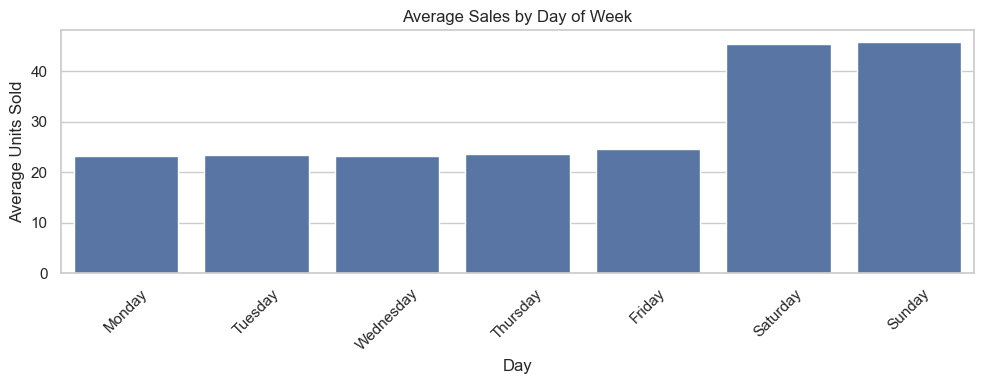

In [18]:
# Cell 6 — Day-of-Week Seasonality

df["day_name"] = df["date"].dt.day_name()

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

dow_summary = (
    df.groupby("day_name", as_index=False)["sales_units"]
      .mean()
)

dow_summary["day_name"] = pd.Categorical(
    dow_summary["day_name"],
    categories=day_order,
    ordered=True,
)

dow_summary = dow_summary.sort_values("day_name")
display(dow_summary)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=dow_summary,
    x="day_name",
    y="sales_units",
)
plt.title("Average Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# Cell 7 — Promotional Lift Analysis

# In src/data_generator.py, `on_promotion` is stored as:
# 0 = not on promotion
# 1 = on promotion

promo_summary = (
    df.groupby(["category", "on_promotion"])["sales_units"]
      .agg(["mean", "median", "count"])
      .reset_index()
)

display(promo_summary)

promo_means = (
    df.groupby(["category", "on_promotion"])["sales_units"]
      .mean()
      .unstack(fill_value=0)
)

print("Promotion-status columns:", promo_means.columns.tolist())

if 0 in promo_means.columns and 1 in promo_means.columns:
    baseline = promo_means[0]
    promoted = promo_means[1]

    promo_lift = (
        (promoted - baseline)
        / baseline.replace(0, np.nan)
        * 100
    ).rename("lift_pct")

    promo_lift = promo_lift.sort_values(ascending=False)

    print("\nEstimated promotional lift by category:")
    display(promo_lift.to_frame())
else:
    print("Both promotion states (0 and 1) were not observed in the generated data.")

,category,on_promotion,mean,median,count
0,Bakery,0,21.494530,19.0,11152
1,Bakery,1,27.604167,25.0,528
2,Dairy,0,45.639879,40.0,11224
3,Dairy,1,70.013158,61.5,456
4,Meat,0,23.414516,21.0,11160
5,Meat,1,33.032692,28.0,520
6,Produce,0,27.150178,24.0,11240
7,Produce,1,36.081818,32.0,440


Promotion-status columns: [0, 1]

Estimated promotional lift by category:


,lift_pct
category,
Dairy,53.403470
Meat,41.077834
Produce,32.897170
Bakery,28.424146


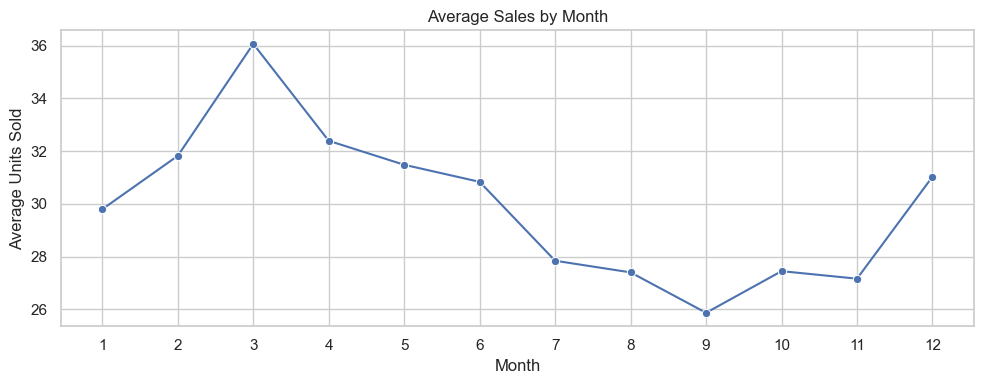

In [20]:
# Cell 8 — Monthly / Yearly Seasonality

df["month"] = df["date"].dt.month

monthly_summary = (
    df.groupby("month", as_index=False)["sales_units"]
      .mean()
)

plt.figure(figsize=(10, 4))
sns.lineplot(
    data=monthly_summary,
    x="month",
    y="sales_units",
    marker="o",
)
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [21]:
# Cell 9 — Cost / Shelf-Life Sanity Check

cost_columns = [
    "base_price",
    "unit_cost",
    "holding_cost_per_day",
    "spoilage_cost_per_unit",
    "stockout_cost_per_unit",
    "shelf_life_days",
]

display(df[cost_columns].describe().T)

print("\nAverage shelf life by category:")
display(
    df.groupby("category")["shelf_life_days"]
      .first()
      .sort_values()
      .to_frame("shelf_life_days")
)

,count,mean,std,min,25%,50%,75%,max
base_price,46720.0,69.013250,56.764217,21.63,29.9975,44.200,79.7950,206.53
unit_cost,46720.0,40.624333,35.477147,13.36,15.8200,26.820,43.7550,129.83
holding_cost_per_day,46720.0,1.333924,1.374139,0.29,0.5100,0.750,1.5100,5.11
spoilage_cost_per_unit,46720.0,45.863646,34.156513,18.09,21.0375,33.815,49.9575,135.79
stockout_cost_per_unit,46720.0,77.550919,21.249180,54.43,62.5000,67.510,86.0600,124.40
shelf_life_days,46720.0,4.750000,1.479036,3.00,3.7500,4.500,5.5000,7.00



Average shelf life by category:


,shelf_life_days
category,
Bakery,3
Produce,4
Meat,5
Dairy,7


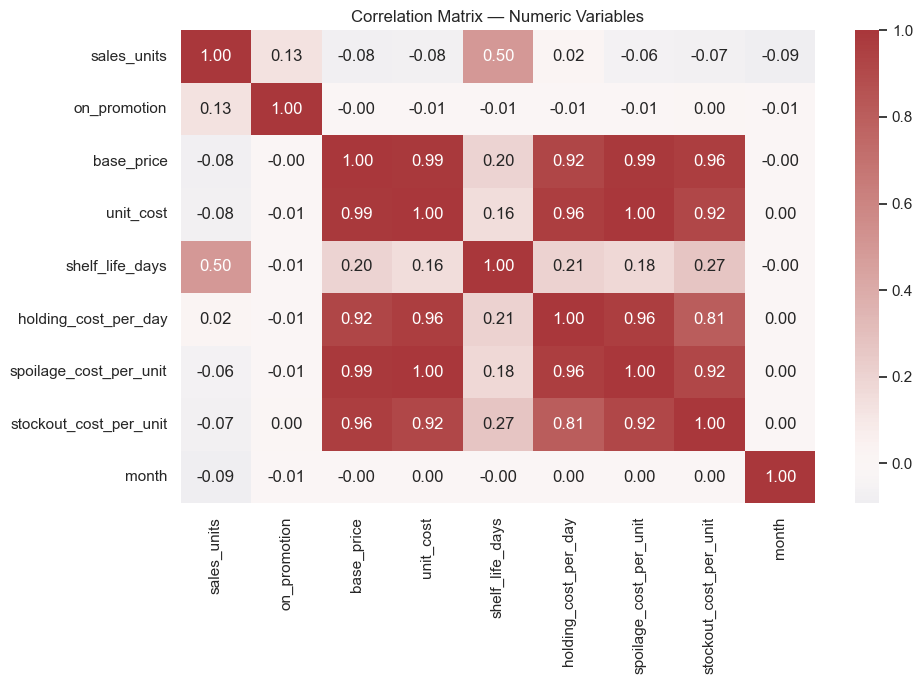

In [22]:
# Cell 10 — Correlation View for Numeric Columns

numeric_cols = df.select_dtypes(include=np.number).columns

if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr()

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        center=0,
    )
    plt.title("Correlation Matrix — Numeric Variables")
    plt.tight_layout()
    plt.show()

## Notebook 1 — What you should understand

Before moving to forecasting, you should be able to explain:

- `sales_units` is the forecasting target.
- `on_promotion` is encoded as **0/1** in the current source.
- Weekend, festival, month-end and promotion effects are intentionally embedded
  in the synthetic generator.
- `lead_time_meta` is a separate dictionary containing supplier lead-time probabilities.
- EDA is used to validate that the data generator produced the patterns we expect.